In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
print(sys.executable)

c:\ProgramData\anaconda3c\python.exe


In [6]:
import pandas as pd

df = pd.read_csv("C:/Users/Lenovo P52S/OneDrive/Desktop/ML Project/tmdb_5000_movies.csv")
print(df.head())

      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"id": 470, "nam

In [10]:
import pandas as pd

# define path
path = "C:/Users/Lenovo P52S/OneDrive/Desktop/ML Project/"

# load datasets
movies = pd.read_csv(path + "tmdb_5000_movies.csv")
credits = pd.read_csv(path + "tmdb_5000_credits.csv")

# view data
movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [11]:
import pandas as pd
import json

# Load dataset (make sure path is correct)
movies = pd.read_csv("C:/Users/Lenovo P52S/OneDrive/Desktop/ML Project/tmdb_5000_movies.csv")

# -------- KEYWORDS --------
movies['keywords'] = movies['keywords'].fillna('[]')

keywords = movies[['id', 'title', 'keywords']].copy()

# convert JSON string → list
keywords['keywords'] = keywords['keywords'].apply(json.loads)

# explode list into rows
keywords = keywords.explode('keywords')

# extract keyword name
keywords['keyword'] = keywords['keywords'].apply(lambda x: x['name'] if isinstance(x, dict) else None)

# final columns
keywords = keywords[['id', 'title', 'keyword']]

# -------- GENRES --------
movies['genres'] = movies['genres'].fillna('[]')

genres = movies[['id', 'title', 'genres']].copy()

genres['genres'] = genres['genres'].apply(json.loads)

genres = genres.explode('genres')

genres['genre'] = genres['genres'].apply(lambda x: x['name'] if isinstance(x, dict) else None)

genres = genres[['id', 'title', 'genre']]

# view results
print(keywords.head())
print(genres.head())

      id   title        keyword
0  19995  Avatar  culture clash
0  19995  Avatar         future
0  19995  Avatar      space war
0  19995  Avatar   space colony
0  19995  Avatar        society
      id                                     title            genre
0  19995                                    Avatar           Action
0  19995                                    Avatar        Adventure
0  19995                                    Avatar          Fantasy
0  19995                                    Avatar  Science Fiction
1    285  Pirates of the Caribbean: At World's End        Adventure


In [13]:
print(genres.head(14))

       id                                     title            genre
0   19995                                    Avatar           Action
0   19995                                    Avatar        Adventure
0   19995                                    Avatar          Fantasy
0   19995                                    Avatar  Science Fiction
1     285  Pirates of the Caribbean: At World's End        Adventure
1     285  Pirates of the Caribbean: At World's End          Fantasy
1     285  Pirates of the Caribbean: At World's End           Action
2  206647                                   Spectre           Action
2  206647                                   Spectre        Adventure
2  206647                                   Spectre            Crime
3   49026                     The Dark Knight Rises           Action
3   49026                     The Dark Knight Rises            Crime
3   49026                     The Dark Knight Rises            Drama
3   49026                     The 

In [15]:
import pandas as pd

# assume 'genres' already created like before
genres3 = genres.copy()

# create order column (like R loop)
genres3['order'] = genres3.groupby('id').cumcount() + 1

# keep only first 3 genres
genres3 = genres3[genres3['order'] < 4]

# pivot (spread)
genres3 = genres3.pivot(index='id', columns='order', values='genre').reset_index()

# rename columns
genres3.columns = ['id', 'genre_1', 'genre_2', 'genre_3']

# merge with movies
movies = movies.merge(genres3, on='id', how='left')

# display selected ids
selected = genres3[genres3['id'].isin([19995, 285, 206647, 49026])]
print(selected)

          id    genre_1    genre_2  genre_3
131      285  Adventure    Fantasy   Action
2702   19995     Action  Adventure  Fantasy
3464   49026     Action      Crime    Drama
4313  206647     Action  Adventure    Crime


In [17]:
credits.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [21]:
cast = credits[['movie_id', 'title', 'cast']]
print(cast.head())

   movie_id                                     title  \
0     19995                                    Avatar   
1       285  Pirates of the Caribbean: At World's End   
2    206647                                   Spectre   
3     49026                     The Dark Knight Rises   
4     49529                               John Carter   

                                                cast  
0  [{"cast_id": 242, "character": "Jake Sully", "...  
1  [{"cast_id": 4, "character": "Captain Jack Spa...  
2  [{"cast_id": 1, "character": "James Bond", "cr...  
3  [{"cast_id": 2, "character": "Bruce Wayne / Ba...  
4  [{"cast_id": 5, "character": "John Carter", "c...  


In [30]:
cast[cast['actor'] == "Leonardo DiCaprio"]

,movie_id,title,cast,actor
25,597,Titanic,"{'cast_id': 21, 'character': 'Jack Dawson', 'c...",Leonardo DiCaprio
49,64682,The Great Gatsby,"{'cast_id': 2, 'character': 'Jay Gatsby', 'cre...",Leonardo DiCaprio
96,27205,Inception,"{'cast_id': 1, 'character': 'Dom Cobb', 'credi...",Leonardo DiCaprio
176,281957,The Revenant,"{'cast_id': 1, 'character': 'Hugh Glass', 'cre...",Leonardo DiCaprio
250,2567,The Aviator,"{'cast_id': 1, 'character': 'Howard Hughes', '...",Leonardo DiCaprio
287,68718,Django Unchained,"{'cast_id': 3, 'character': 'Calvin Candie', '...",Leonardo DiCaprio
297,1372,Blood Diamond,"{'cast_id': 27, 'character': 'Danny Archer', '...",Leonardo DiCaprio
298,106646,The Wolf of Wall Street,"{'cast_id': 8, 'character': 'Jordan Belfort', ...",Leonardo DiCaprio
316,3131,Gangs of New York,"{'cast_id': 2, 'character': 'Amsterdam Vallon'...",Leonardo DiCaprio
351,1422,The Departed,"{'cast_id': 2, 'character': 'William ""Billy"" C...",Leonardo DiCaprio


In [32]:
cast['character'] = cast['cast'].apply(
    lambda x: x['character'] if isinstance(x, dict) and 'character' in x else None
)

In [34]:
import pandas as pd


titanic = cast[cast['title'] == "Titanic"].copy()


if 'order' not in titanic.columns:
    titanic['order'] = titanic.groupby('title').cumcount() + 1


cols = ['title', 'order', 'actor', 'character']
cols = [c for c in cols if c in titanic.columns]

result = titanic[cols].sort_values('order').head(10)

result

,title,order,actor,character
25,Titanic,1,Kate Winslet,Rose DeWitt Bukater
25,Titanic,2,Leonardo DiCaprio,Jack Dawson
25,Titanic,3,Frances Fisher,Ruth Dewitt Bukater
25,Titanic,4,Billy Zane,Caledon 'Cal' Hockley
25,Titanic,5,Kathy Bates,Molly Brown
25,Titanic,6,Gloria Stuart,Old Rose
25,Titanic,7,Bill Paxton,Brock Lovett
25,Titanic,8,Bernard Hill,Captain Edward James Smith
25,Titanic,9,David Warner,Spicer Lovejoy
25,Titanic,10,Victor Garber,Thomas Andrews


In [37]:
# count actors
cast1 = cast['actor'].value_counts().reset_index()
cast1.columns = ['actor', 'count']

# create order column
cast['order'] = cast.groupby('movie_id').cumcount()

# filter top 3 actors per movie
cast = cast[cast['order'].isin([0, 1, 2])][['movie_id', 'title', 'order', 'actor']]

# check movie 453
cast[cast['movie_id'] == 453]

,movie_id,title,order,actor
493,453,A Beautiful Mind,0,Russell Crowe
493,453,A Beautiful Mind,1,Ed Harris
493,453,A Beautiful Mind,2,Jennifer Connelly


In [38]:
cast['order'] = cast.groupby('movie_id').cumcount()

cast = cast[cast['order'].isin([0, 1, 2])]

cast_wide = cast.pivot(index='movie_id', columns='order', values='actor').reset_index()

cast_wide.columns = ['movie_id', 'actor_1', 'actor_2', 'actor_3']

cast_wide = cast_wide.merge(cast[['movie_id', 'title']].drop_duplicates(), on='movie_id', how='left')

cast_wide[cast_wide['title'].isin(['Titanic', 'Avatar', 'A Beautiful Mind'])]

,movie_id,actor_1,actor_2,actor_3,title
194,453,Russell Crowe,Ed Harris,Jennifer Connelly,A Beautiful Mind
256,597,Kate Winslet,Leonardo DiCaprio,Frances Fisher,Titanic
2702,19995,Sam Worthington,Zoe Saldana,Sigourney Weaver,Avatar


In [39]:
cast['order'] = cast.groupby('movie_id').cumcount()

cast = cast[cast['order'].isin([0, 1, 2])]

cast_wide = cast.pivot(index='movie_id', columns='order', values='actor').reset_index()

cast_wide.columns = ['movie_id', 'actor_1', 'actor_2', 'actor_3']

cast_wide = cast_wide.merge(cast[['movie_id', 'title']].drop_duplicates(), on='movie_id', how='left')

cast_wide[cast_wide['title'].isin(['Titanic', 'Avatar', 'A Beautiful Mind'])]

,movie_id,actor_1,actor_2,actor_3,title
194,453,Russell Crowe,Ed Harris,Jennifer Connelly,A Beautiful Mind
256,597,Kate Winslet,Leonardo DiCaprio,Frances Fisher,Titanic
2702,19995,Sam Worthington,Zoe Saldana,Sigourney Weaver,Avatar


In [42]:
cast = cast.pivot(index='movie_id', columns='order', values='actor').reset_index()

In [43]:
import pandas as pd
import json

# load dataset (if not already loaded)
credits = pd.read_csv("C:/Users/Lenovo P52S/OneDrive/Desktop/ML Project/tmdb_5000_credits.csv")

# fill missing values
credits['crew'] = credits['crew'].fillna('[]')

# keep required columns
crew = credits[['movie_id', 'title', 'crew']].copy()

# convert JSON string → Python list
crew['crew'] = crew['crew'].apply(json.loads)

# explode list into rows
crew = crew.explode('crew')

# extract useful fields
crew['crew_name'] = crew['crew'].apply(lambda x: x['name'] if isinstance(x, dict) else None)
crew['crew_id'] = crew['crew'].apply(lambda x: x['id'] if isinstance(x, dict) else None)
crew['job'] = crew['crew'].apply(lambda x: x['job'] if isinstance(x, dict) else None)

# drop original JSON column
crew = crew.drop(columns=['crew'])

# view structure (glimpse equivalent)
crew.info()

# preview data
crew.head()

<class 'pandas.core.frame.DataFrame'>
Index: 129609 entries, 0 to 4802
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   movie_id   129609 non-null  int64  
 1   title      129609 non-null  object 
 2   crew_name  129581 non-null  object 
 3   crew_id    129581 non-null  float64
 4   job        129581 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 5.9+ MB


,movie_id,title,crew_name,crew_id,job
0,19995,Avatar,Stephen E. Rivkin,1721.0,Editor
0,19995,Avatar,Rick Carter,496.0,Production Design
0,19995,Avatar,Christopher Boyes,900.0,Sound Designer
0,19995,Avatar,Christopher Boyes,900.0,Supervising Sound Editor
0,19995,Avatar,Mali Finn,1262.0,Casting


In [44]:
crew[crew['crew_name'] == "James Cameron"]

,movie_id,title,crew_name,crew_id,job
0,19995,Avatar,James Cameron,2710.0,Director
0,19995,Avatar,James Cameron,2710.0,Writer
0,19995,Avatar,James Cameron,2710.0,Editor
0,19995,Avatar,James Cameron,2710.0,Producer
0,19995,Avatar,James Cameron,2710.0,Screenplay
25,597,Titanic,James Cameron,2710.0,Screenplay
25,597,Titanic,James Cameron,2710.0,Director
25,597,Titanic,James Cameron,2710.0,Editor
25,597,Titanic,James Cameron,2710.0,Producer
93,296,Terminator 3: Rise of the Machines,James Cameron,2710.0,Characters


In [ ]:
directors = crew[crew['job'] == "Director"]

director_count = directors.groupby('movie_id').size().reset_index(name='n')

movies1Director = director_count[director_count['n'] == 1]

valid_directors = directors[directors['movie_id'].isin(movies1Director['movie_id'])]

movies = movies.merge(
    valid_directors[['movie_id', 'crew_name']],
    left_on='id',
    right_on='movie_id',
    how='left'
)

movies.rename(columns={'crew_name': 'director'}, inplace=True)
movies.drop(columns=['movie_id'], inplace=True)

In [46]:
print("Minimum votes:", movies['vote_count'].min())
print("Maximum votes:", movies['vote_count'].max())

Minimum votes: 0
Maximum votes: 13752


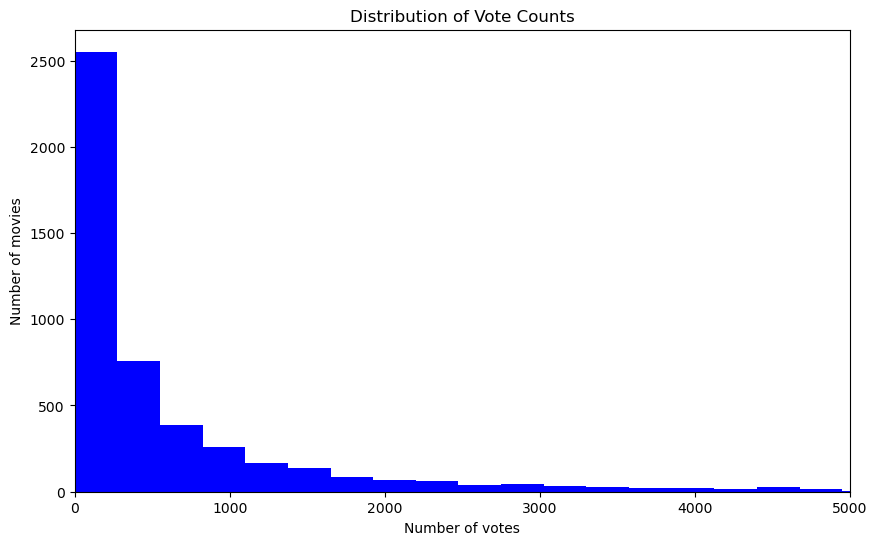

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

plt.hist(movies['vote_count'], bins=50, color='blue')

plt.xlim(0, 5000)

plt.xlabel("Number of votes")
plt.ylabel("Number of movies")
plt.title("Distribution of Vote Counts")

plt.show()

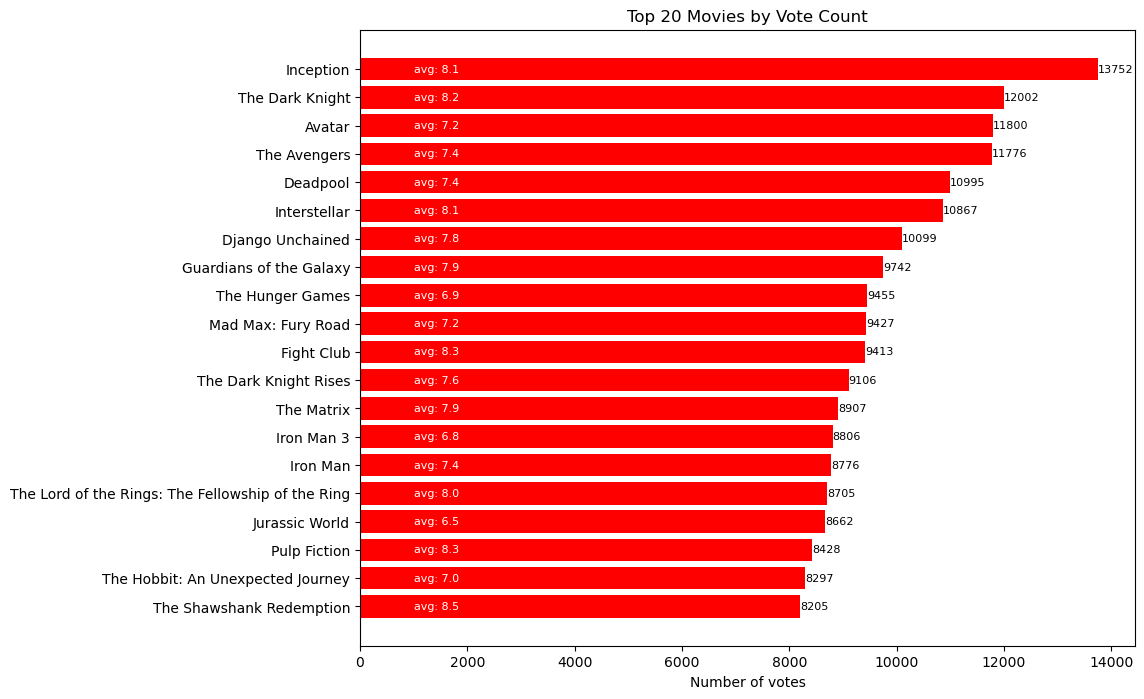

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Top 20 movies by vote_count
top20 = movies.nlargest(20, 'vote_count')

# Sort for better plotting
top20 = top20.sort_values('vote_count')

plt.figure(figsize=(10,8))

# Horizontal bar chart
plt.barh(top20['title'], top20['vote_count'], color='Red')

# Labels
plt.xlabel("Number of votes")
plt.ylabel("")

# Add vote_count text on bars
for i, v in enumerate(top20['vote_count']):
    plt.text(v, i, str(v), va='center', fontsize=8)

# Add vote_average text (slightly shifted)
for i, v in enumerate(top20['vote_average']):
    plt.text(1000, i, f"avg: {v}", va='center', fontsize=8, color='white')

plt.title("Top 20 Movies by Vote Count")

plt.show()

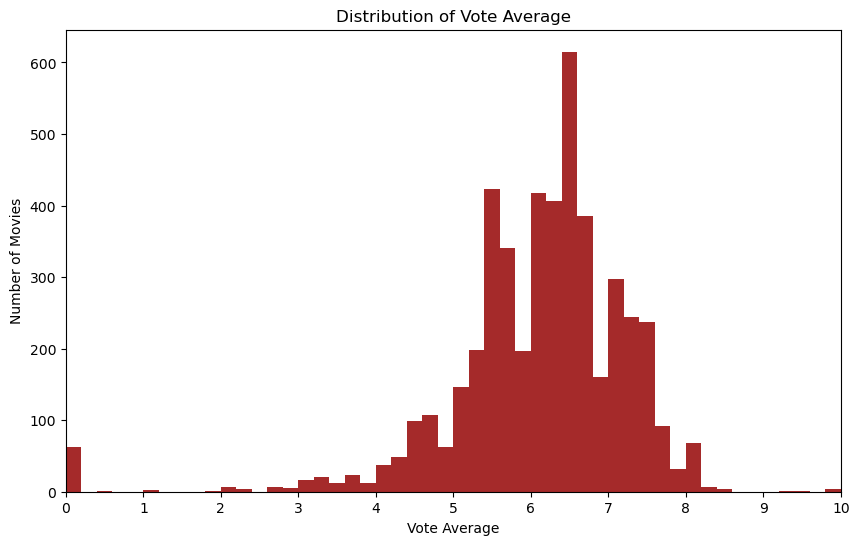

In [55]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

plt.hist(movies['vote_average'], bins=50, color='brown')

plt.xlim(0, 10)
plt.xticks(np.arange(0, 11, 1))

plt.xlabel("Vote Average")
plt.ylabel("Number of Movies")
plt.title("Distribution of Vote Average")

plt.show()

In [56]:
from scipy.stats import skew

skew(movies['vote_average'].dropna())

np.float64(-1.9590979272364033)

In [57]:
result = movies[
    ((movies['vote_average'] < 4.5) | (movies['vote_average'] > 8.5)) &
    (movies['vote_count'] >= 400)
][['id', 'title', 'vote_average', 'vote_count']].sort_values('vote_average')

result

,id,title,vote_average,vote_count
1652,14164,Dragonball Evolution,2.9,462
3843,205321,Sharknado,3.8,476
499,71880,Jack and Jill,4.1,604
259,1639,Speed 2: Cruise Control,4.1,434
3746,241251,The Boy Next Door,4.1,1022
210,415,Batman & Robin,4.2,1418
303,314,Catwoman,4.2,808
242,166424,Fantastic Four,4.4,2278
1035,20533,Jonah Hex,4.4,420
610,188207,The Legend of Hercules,4.4,533


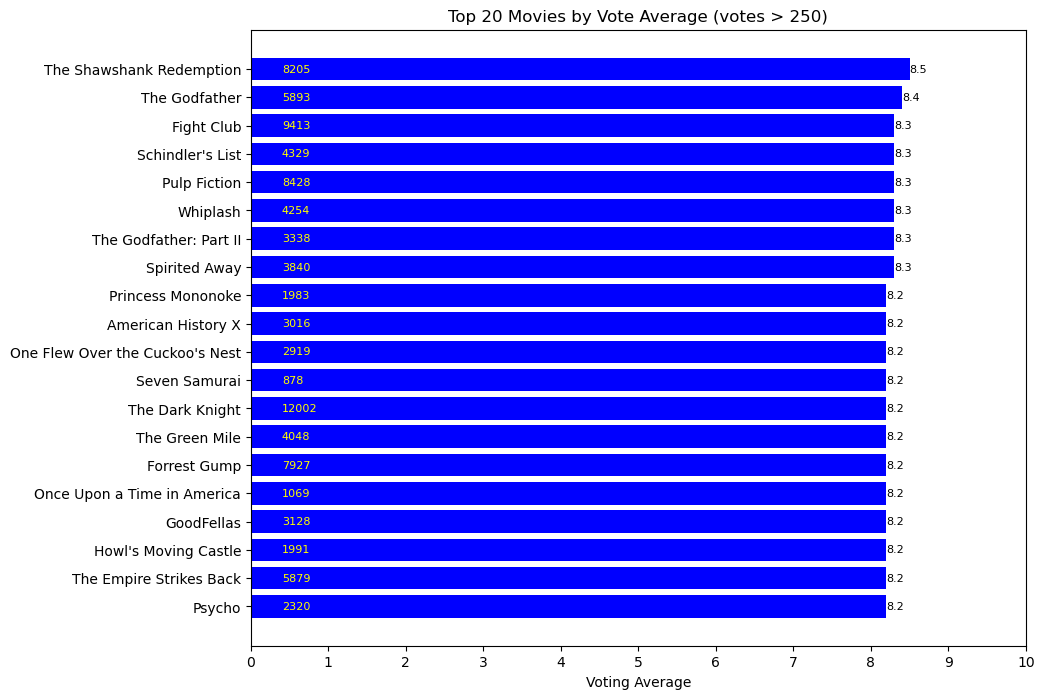

In [58]:
import matplotlib.pyplot as plt

# Step 1: filter data
data = movies[movies['vote_count'] > 250]

# Step 2: top 20 by vote_average
top20 = data.nlargest(20, 'vote_average').sort_values('vote_average')

# Step 3: plot
plt.figure(figsize=(10,8))

plt.barh(top20['title'], top20['vote_average'], color='blue')

plt.xlim(0, 10)
plt.xticks(range(0, 11, 1))

plt.xlabel("Voting Average")
plt.ylabel("")

# Add vote_average labels
for i, v in enumerate(top20['vote_average']):
    plt.text(v, i, f"{v:.1f}", va='center', fontsize=8)

# Add vote_count labels
for i, v in enumerate(top20['vote_count']):
    plt.text(0.4, i, str(v), va='center', fontsize=8, color='yellow')

plt.title("Top 20 Movies by Vote Average (votes > 250)")

plt.show()

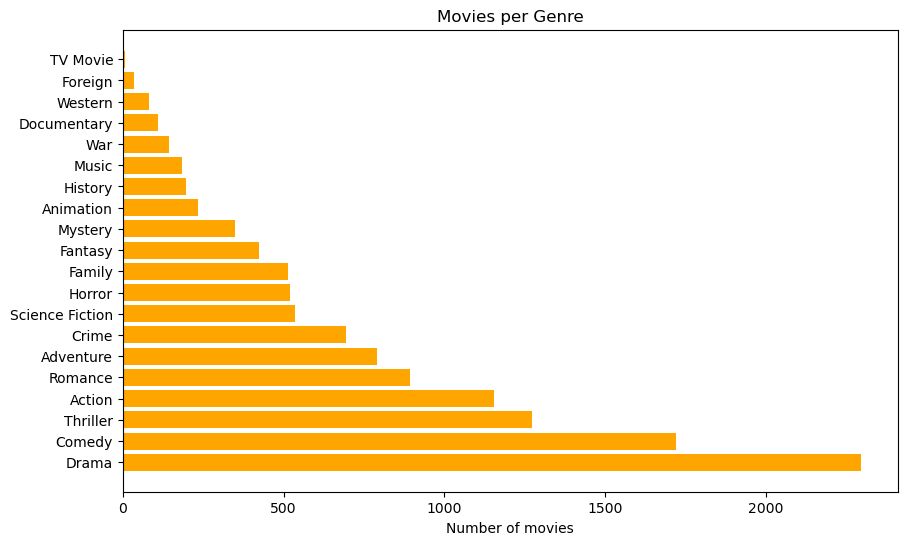

In [65]:
genre_counts = genres['genre'].value_counts().reset_index()
genre_counts.columns = ['genre', 'count']

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(genre_counts['genre'], genre_counts['count'], color='orange')
plt.xlabel("Number of movies")
plt.title("Movies per Genre")
plt.show()


C:\Users\Lenovo P52S\AppData\Local\Temp\ipykernel_33064\3812368921.py:25: UserWarning: Glyph 12450 (\N{KATAKANA LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo P52S\AppData\Local\Temp\ipykernel_33064\3812368921.py:25: UserWarning: Glyph 12461 (\N{KATAKANA LETTER KI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo P52S\AppData\Local\Temp\ipykernel_33064\3812368921.py:25: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo P52S\AppData\Local\Temp\ipykernel_33064\3812368921.py:25: UserWarning: Glyph 12418 (\N{HIRAGANA LETTER MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo P52S\AppData\Local\Temp\ipykernel_33064\3812368921.py:25: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo P52S\AppData\Local\Temp\ipykernel_33064\3812368921.py:25: UserWarning: Glyph 12369 (\N{HIR

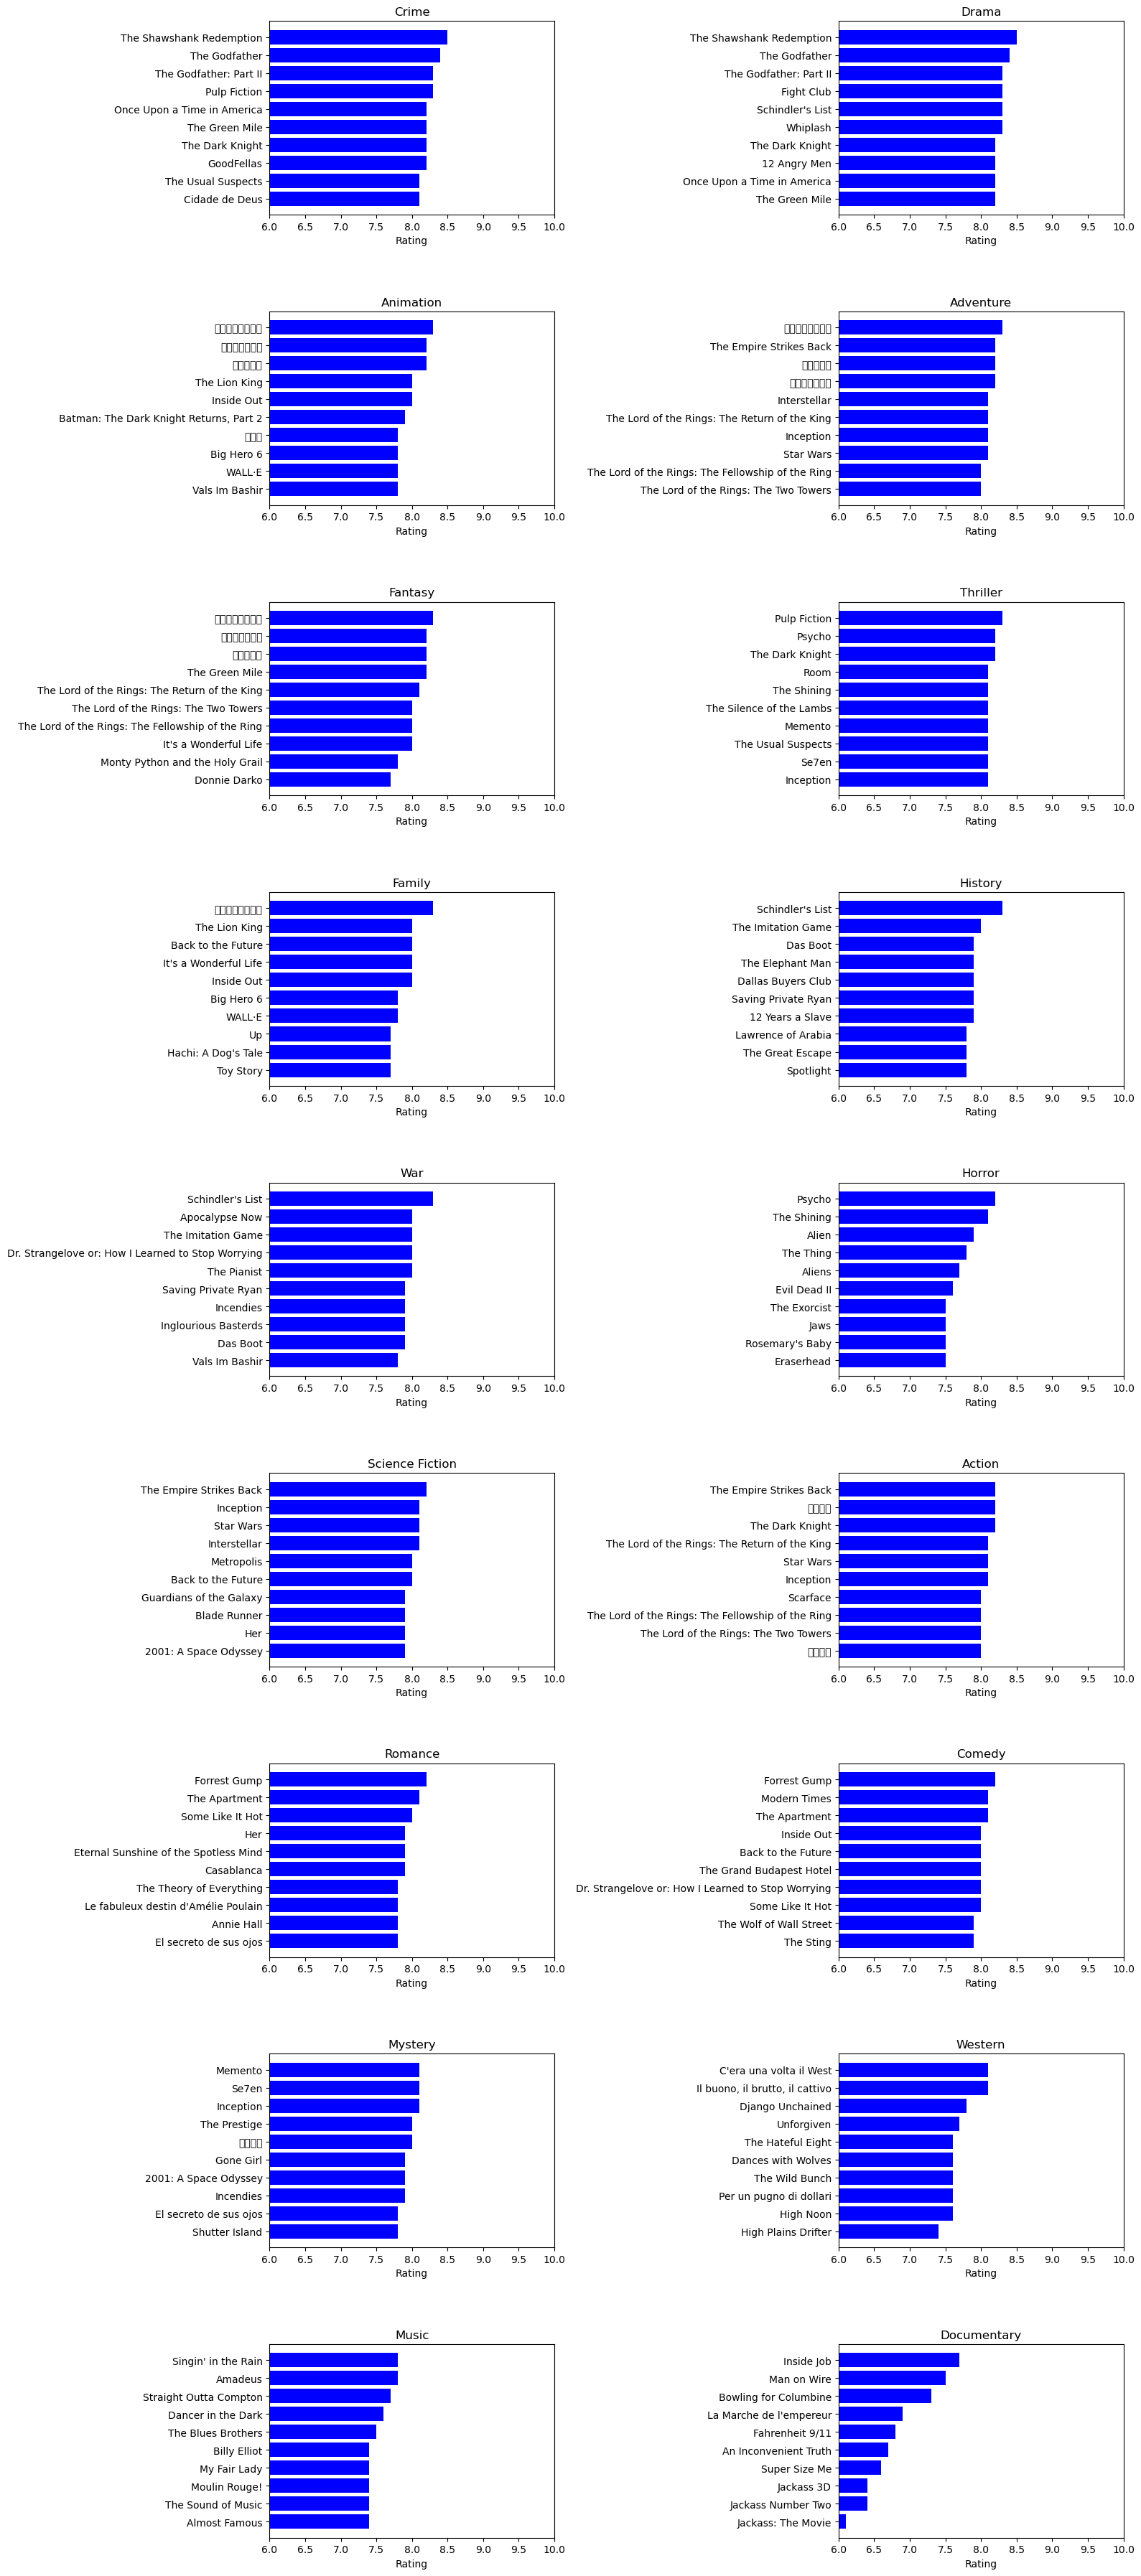

In [ ]:
import matplotlib.pyplot as plt
import math

n = len(genres_list)

cols = 2
rows = math.ceil(n / cols)

plt.figure(figsize=(16, rows * 4))

for i, g in enumerate(genres_list):
    data = top_movies[top_movies['genre'] == g].sort_values('vote_average')

    plt.subplot(rows, cols, i + 1)

    plt.barh(data['title'], data['vote_average'], color= 'blue')

    plt.title(g, fontsize=12)
    plt.xlim(6, 10)

    plt.xlabel("Rating")
    plt.ylabel("")

    plt.tight_layout()

plt.subplots_adjust(hspace=0.5)
plt.show()

In [77]:
top20 = cast1.nlargest(20, 'count').sort_values('count')

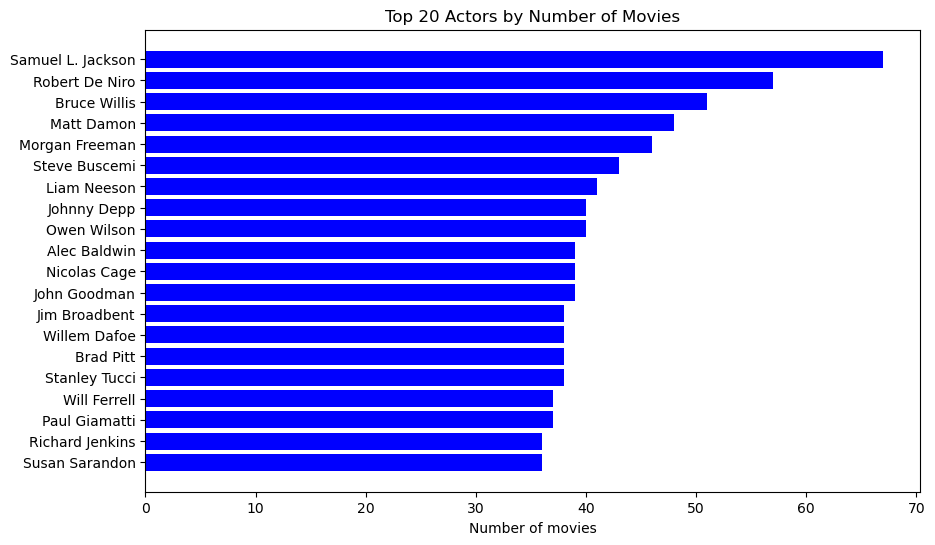

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(top20['actor'], top20['count'], color='blue')

plt.xlabel("Number of movies")
plt.title("Top 20 Actors by Number of Movies")

plt.show()

In [4]:
print(movies.columns)


Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')


In [5]:
df = movies.dropna(subset=['genres'])

genre_counts = df['genres'].value_counts().reset_index()
genre_counts.columns = ['genres', 'count']

print(genre_counts.head())

                                              genres  count
0                      [{"id": 18, "name": "Drama"}]    370
1                     [{"id": 35, "name": "Comedy"}]    282
2  [{"id": 18, "name": "Drama"}, {"id": 10749, "n...    164
3  [{"id": 35, "name": "Comedy"}, {"id": 10749, "...    144
4  [{"id": 35, "name": "Comedy"}, {"id": 18, "nam...    142


In [6]:
# Check duplicate rows
print("Number of duplicate rows:", movies.duplicated().sum())

# Remove duplicate rows
movies = movies.drop_duplicates()

# Verify duplicates removed
print("Duplicate rows after removal:", movies.duplicated().sum())

Number of duplicate rows: 0
Duplicate rows after removal: 0


In [ ]:

print(movies.info())

# Remove unnecessary columns
movies = movies.drop(['homepage', 'tagline'], axis=1)

# Convert release_date to datetime
movies['release_date'] = pd.to_datetime(movies['release_date'])

# Encode categorical column
movies['original_language'] = movies['original_language'].astype('category').cat.codes

# Check transformed dataset
print(movies.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [82]:
len(keywords['keyword'].unique())

9814

In [86]:
keyword_counts = keywords['keyword'].value_counts().reset_index()
keyword_counts.columns = ['keyword', 'count']

In [87]:
top20 = keyword_counts.nlargest(20, 'count').sort_values('count')

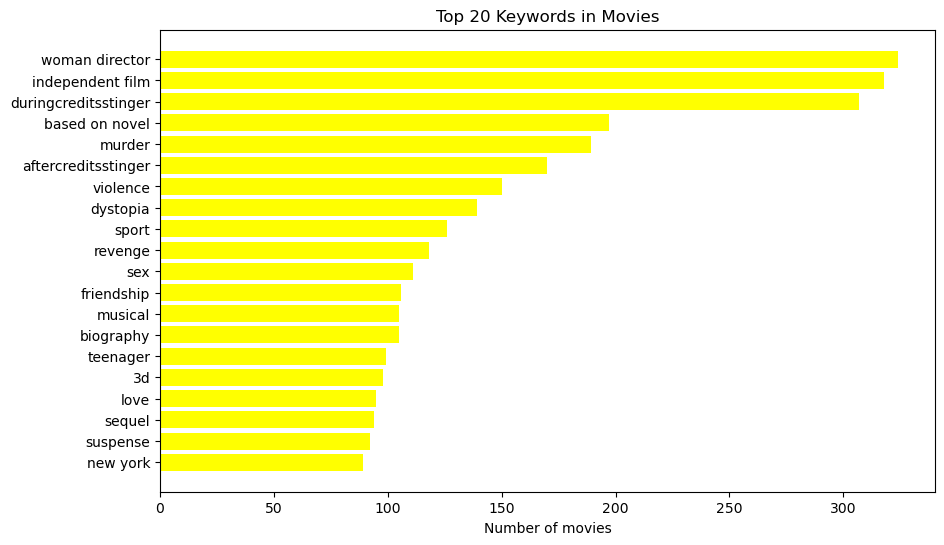

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(top20['keyword'], top20['count'], color='yellow')

plt.xlabel("Number of movies")
plt.ylabel("")
plt.title("Top 20 Keywords in Movies")

plt.show()

In [90]:
from collections import Counter

keywords_counts = Counter(keywords['keyword'])

In [96]:
print(type(keywords_counts))
print(list(keywords_counts.items())[:10])

<class 'dict'>
[('woman director', np.int64(324)), ('independent film', np.int64(318)), ('duringcreditsstinger', np.int64(307)), ('based on novel', np.int64(197)), ('murder', np.int64(189)), ('aftercreditsstinger', np.int64(170)), ('violence', np.int64(150)), ('dystopia', np.int64(139)), ('sport', np.int64(126)), ('revenge', np.int64(118))]


In [101]:
keywords_counts = keywords['keyword'].value_counts().reset_index()

In [113]:
dummy = keywords.groupby(['id', 'title']).size().reset_index(name='n')

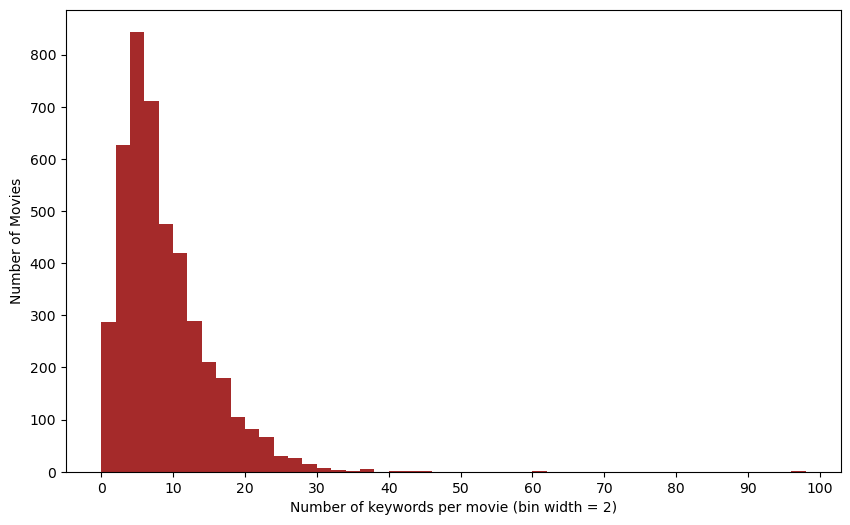

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(dummy['n'], bins=range(0, 100, 2), color='brown')

plt.xlabel("Number of keywords per movie (bin width = 2)")
plt.ylabel("Number of Movies")

plt.xticks(range(0, 101, 10))

plt.show()

In [116]:
dummy = keywords.groupby('id').size().reset_index(name='n')

In [117]:
len(keywords.groupby('id').size().reset_index(name='n')
    .query('n < 3'))

571

In [118]:
len(movies[~movies['id'].isin(keywords['id'])])

412

In [120]:
lang_counts = movies['original_language'].value_counts().reset_index()
lang_counts.columns = ['original_language', 'count']

top10 = lang_counts.nlargest(10, 'count').sort_values('count')

In [121]:
print(movies.columns)

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count', 'genre_1', 'genre_2', 'genre_3', 'director'],
      dtype='object')


In [122]:
import plotly.express as px

lang_counts = movies['original_language'].value_counts().reset_index()
lang_counts.columns = ['original_language', 'count']

top10 = lang_counts.nlargest(10, 'count').sort_values('count')

fig = px.bar(
    top10,
    x='count',
    y='original_language',
    orientation='h',
    color='count',
    title="Top 10 Movie Languages"
)

fig.show()

In [125]:
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')
movies['release_year'] = movies['release_date'].dt.year

df = movies.dropna(subset=['release_year'])

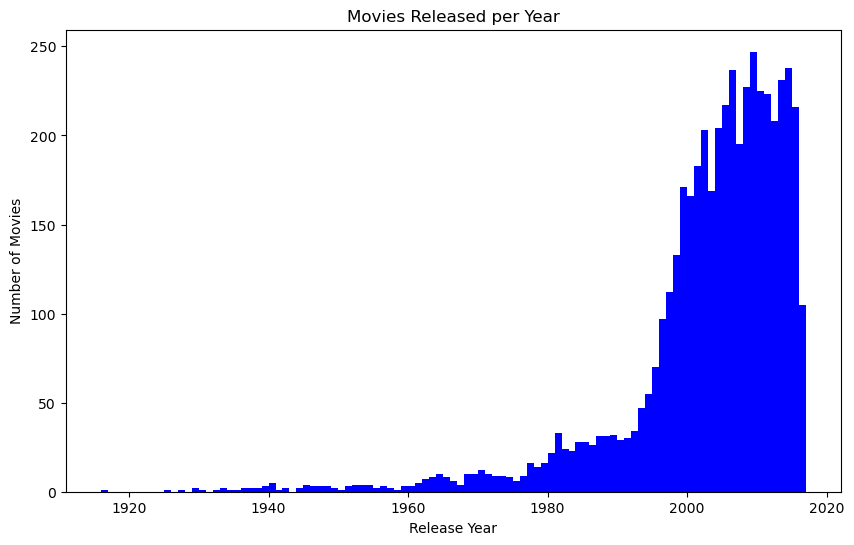

In [126]:
import pandas as pd
import matplotlib.pyplot as plt

movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')
movies['release_year'] = movies['release_date'].dt.year

df = movies.dropna(subset=['release_year'])

plt.figure(figsize=(10,6))

plt.hist(
    df['release_year'],
    bins=range(int(df['release_year'].min()), int(df['release_year'].max()) + 1),
    color='blue'
)

plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.title("Movies Released per Year")

plt.show()

In [127]:
movies.loc[movies['release_year'] == 2016, 'release_date'].agg(['min', 'max'])

min   2016-01-01
max   2016-10-02
Name: release_date, dtype: datetime64[ns]

In [131]:
m = movies['vote_count'].quantile(0.75)

In [129]:
C = movies['vote_average'].mean()
m = movies['vote_count'].quantile(0.75)

print("C (mean rating):", C)
print("m (75th percentile vote count):", m)

C (mean rating): 6.092171559442016
m (75th percentile vote count): 737.0


In [132]:
C = movies['vote_average'].mean()
m = movies['vote_count'].quantile(0.75)

v = movies['vote_count']
R = movies['vote_average']

movies['weighted_rating'] = (v/(v + m)) * R + (m/(v + m)) * C

In [133]:
top_movies = movies.sort_values('weighted_rating', ascending=False)[
    ['title', 'vote_average', 'vote_count', 'weighted_rating']
].head(10)

top_movies

,title,vote_average,vote_count,weighted_rating
1881,The Shawshank Redemption,8.5,8205,8.301547
3337,The Godfather,8.4,5893,8.143459
662,Fight Club,8.3,9413,8.139688
3232,Pulp Fiction,8.3,8428,8.122458
65,The Dark Knight,8.2,12002,8.078054
809,Forrest Gump,8.2,7927,8.020698
96,Inception,8.1,13752,7.997869
1818,Schindler's List,8.3,4329,7.978806
3865,Whiplash,8.3,4254,7.973979
95,Interstellar,8.1,10867,7.972478


In [134]:
top20 = movies.sort_values('weighted_rating', ascending=False).head(20)

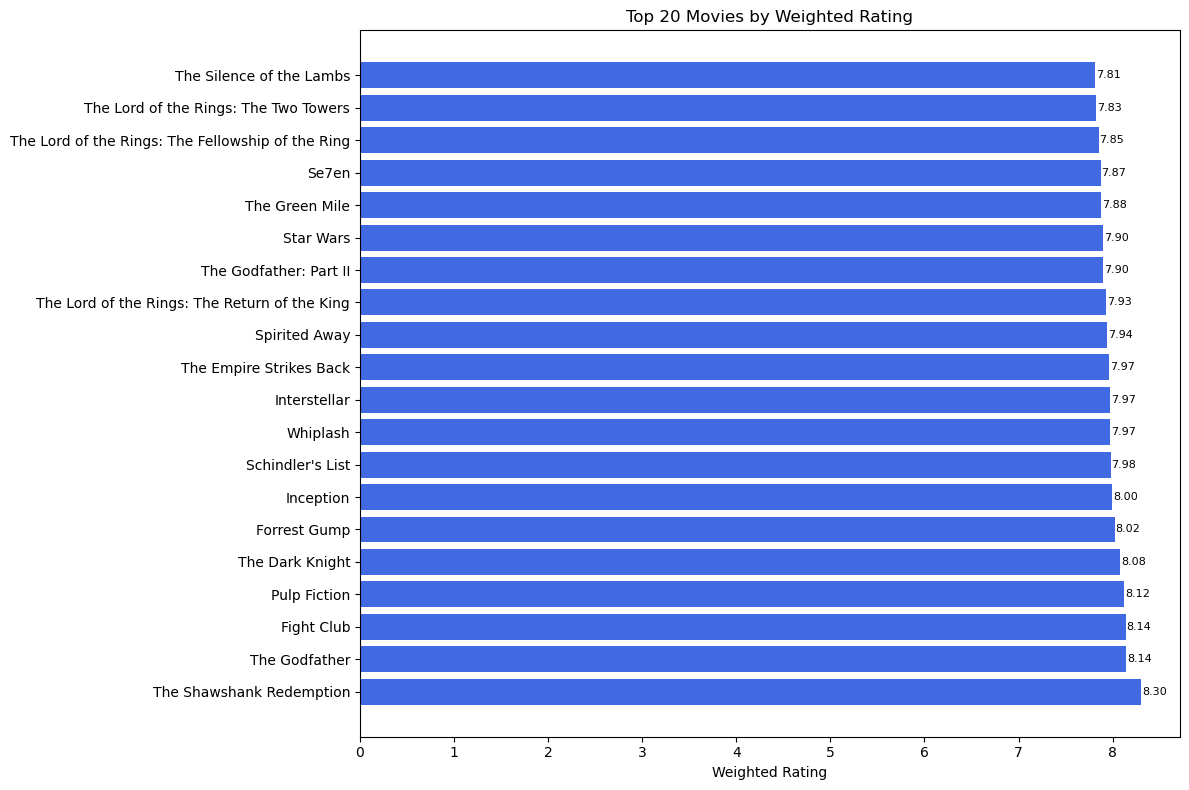

In [136]:
import matplotlib.pyplot as plt

# sort properly (important for clean chart)
top20_sorted = top20.sort_values('weighted_rating')

plt.figure(figsize=(12,8))

bars = plt.barh(
    top20_sorted['title'],
    top20_sorted['weighted_rating'],
    color='royalblue'  
)

plt.xlabel("Weighted Rating")
plt.title("Top 20 Movies by Weighted Rating")

plt.gca().invert_yaxis()

for i, (rating, votes) in enumerate(zip(
        top20_sorted['weighted_rating'],
        top20_sorted['vote_count'])):
    plt.text(rating + 0.01, i,
             f"{rating:.2f}",
             fontsize=8,
             va='center')

plt.tight_layout()
plt.show()

<BarContainer object of 20 artists>

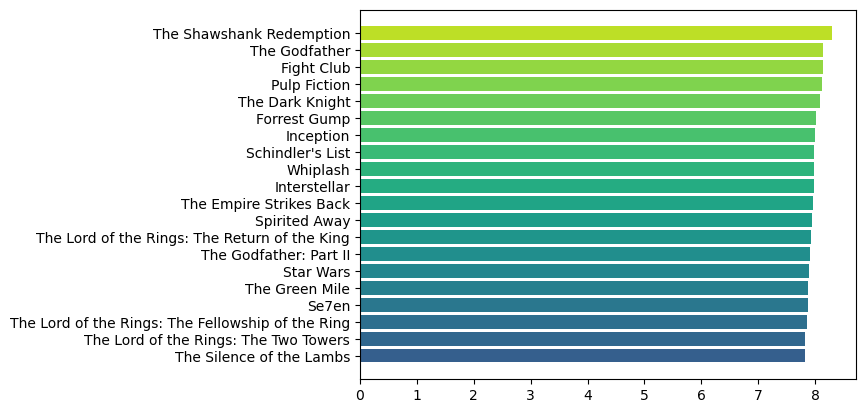

In [137]:
import numpy as np

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top20_sorted)))

plt.barh(top20_sorted['title'], top20_sorted['weighted_rating'], color=colors)

In [147]:
genres250 = genres250.merge(movies[['id','weighted_rating']], on='id')

In [141]:
def recommend_genre_language(genre, language="en"):
    return (
        genres250[
            (genres250['original_language'] == language) &
            (genres250['genres'] == genre)
        ]
        .sort_values('weighted_rating', ascending=False)
        .head(5)
    )
    

In [149]:
print(genres250.columns)
print(genres250.head(3))

Index(['id', 'title', 'genre', 'vote_average', 'vote_count',
       'original_language', 'original_title', 'weighted_rating'],
      dtype='object')
      id   title      genre  vote_average  vote_count original_language  \
0  19995  Avatar     Action           7.2     11800.0                en   
1  19995  Avatar  Adventure           7.2     11800.0                en   
2  19995  Avatar    Fantasy           7.2     11800.0                en   

  original_title  weighted_rating  
0         Avatar         7.134875  
1         Avatar         7.134875  
2         Avatar         7.134875  


In [151]:
print(genres250.head())
print(genres250.columns)
print(genres250.shape)

      id                                     title            genre  \
0  19995                                    Avatar           Action   
1  19995                                    Avatar        Adventure   
2  19995                                    Avatar          Fantasy   
3  19995                                    Avatar  Science Fiction   
4    285  Pirates of the Caribbean: At World's End        Adventure   

   vote_average  vote_count original_language  \
0           7.2     11800.0                en   
1           7.2     11800.0                en   
2           7.2     11800.0                en   
3           7.2     11800.0                en   
4           6.9      4500.0                en   

                             original_title  weighted_rating  
0                                    Avatar         7.134875  
1                                    Avatar         7.134875  
2                                    Avatar         7.134875  
3                         

In [158]:
required_cols = [
    'id', 'title',
    'actor_1', 'actor_2', 'actor_3',
    'director',
    'genre_1', 'genre_2', 'genre_3',
    'weighted_rating'
]

missing = [col for col in required_cols if col not in movies.columns]

if missing:
    print("Missing columns:", missing)
else:
    movies_clean = movies[required_cols].drop_duplicates(subset='id')
    print("movies_clean created successfully!")


Missing columns: ['actor_1', 'actor_2', 'actor_3']


In [8]:
def recommend_similar(movie_id):

    df = movies_clean.copy()

    if movie_id not in df['id'].values:
        return "Movie ID not found"

    m = df[df['id'] == movie_id].iloc[0]

    df['same_director'] = (df['director'] == m['director']).astype(int)

    df['same_actor'] = (
        df[['actor_1','actor_2','actor_3']]
        .isin([m['actor_1'], m['actor_2'], m['actor_3']])
        .any(axis=1)
    ).astype(int)

    df['same_genre'] = (
        df[['genre_1','genre_2','genre_3']]
        .isin([m['genre_1'], m['genre_2'], m['genre_3']])
        .any(axis=1)
    ).astype(int)

    df['sim_count'] = df['same_director'] + df['same_actor'] + df['same_genre']

    df = df[df['id'] != movie_id]

    return df.sort_values(
        ['sim_count', 'weighted_rating'],
        ascending=False
    )[[
        'id','title','sim_count','weighted_rating'
    ]].head(5)

In [164]:
print(movies.columns)

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count', 'genre_1', 'genre_2', 'genre_3', 'director',
       'release_year', 'weighted_rating'],
      dtype='object')


In [167]:
plots = movies[['id', 'title', 'overview']].copy()
plots.rename(columns={'overview': 'text'}, inplace=True)

In [168]:
plots.loc[plots['id'] == 597, 'text'].values[0]

'84 years later, a 101-year-old woman named Rose DeWitt Bukater tells the story to her granddaughter Lizzy Calvert, Brock Lovett, Lewis Bodine, Bobby Buell and Anatoly Mikailavich on the Keldysh about her life set in April 10th 1912, on a ship called Titanic when young Rose boards the departing ship with the upper-class passengers and her mother, Ruth DeWitt Bukater, and her fiancé, Caledon Hockley. Meanwhile, a drifter and artist named Jack Dawson and his best friend Fabrizio De Rossi win third-class tickets to the ship in a game. And she explains the whole story from departure until the death of Titanic on its first and last voyage April 15th, 1912 at 2:20 in the morning.'

In [171]:
plots = movies[['id', 'title', 'overview']].dropna().copy()
plots.rename(columns={'overview': 'text'}, inplace=True)

In [172]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(plots['text'])

In [173]:
import pandas as pd

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=plots['id'],
    columns=tfidf.get_feature_names_out()
)

In [175]:
keywords[keywords['id'] == 597].reset_index(drop=True)

,id,title,keyword
0,597,Titanic,shipwreck
1,597,Titanic,iceberg
2,597,Titanic,ship
3,597,Titanic,panic
4,597,Titanic,titanic
5,597,Titanic,ocean liner
6,597,Titanic,epic
7,597,Titanic,rich woman - poor man
8,597,Titanic,love
9,597,Titanic,disaster


In [183]:
path1 = r"C:\Users\Lenovo P52S\OneDrive\Desktop\ML Project/tmdb_5000_movies.csv"

In [186]:
movie_names = pd.read_csv(
    "tmdb_5000_movies.csv",
    usecols=["id", "title"]
)

In [190]:
import os
os.getcwd()

'c:\\Users\\Lenovo P52S\\OneDrive\\Desktop\\ML Project'

In [192]:
plots = movies[['id', 'title', 'overview']].copy()
plots.rename(columns={'overview': 'text'}, inplace=True)

In [193]:
def top_words(movie_id, n=10):
    if movie_id not in tfidf_df.index:
        return "Movie not found"

    top = tfidf_df.loc[movie_id].sort_values(ascending=False).head(n)
    return top

In [194]:
cosine_similarity(tfidf_matrix)

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.        , ..., 0.03025952, 0.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.02084631, 0.        ,
        0.        ],
       ...,
       [0.        , 0.03025952, 0.02084631, ..., 1.        , 0.02321443,
        0.01000466],
       [0.        , 0.        , 0.        , ..., 0.02321443, 1.        ,
        0.01707698],
       [0.        , 0.        , 0.        , ..., 0.01000466, 0.01707698,
        1.        ]])

In [195]:
keywords[keywords['id'] == 597].reset_index(drop=True)

,id,title,keyword
0,597,Titanic,shipwreck
1,597,Titanic,iceberg
2,597,Titanic,ship
3,597,Titanic,panic
4,597,Titanic,titanic
5,597,Titanic,ocean liner
6,597,Titanic,epic
7,597,Titanic,rich woman - poor man
8,597,Titanic,love
9,597,Titanic,disaster


In [203]:
ratings_small = pd.read_csv("tmdb_5000_movies.csv")

In [212]:
ratings_small.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [206]:
print(ratings_small.columns)

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')


In [213]:
ratings_small.columns = ratings_small.columns.str.strip().str.lower()

In [217]:
ratings_small.shape

(4803, 20)

In [219]:
print(ratings_small.shape)
print(ratings_small.columns)
print(ratings_small.head())
print(ratings_small.dtypes)

(4803, 20)
Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')
      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3          

In [224]:
type(ratings_small)

pandas.core.frame.DataFrame

In [225]:
ratings_small.shape

(4803, 20)

In [241]:
index="user_id"
columns="movie_id"
values="rating"

In [ ]:
import pandas as pd

ratings_small = pd.read_csv("tmdb_5000_movies.csv")


In [250]:
movies = pd.read_csv("tmdb_5000_movies.csv")

movies[['title', 'vote_average', 'vote_count']]

,title,vote_average,vote_count
0,Avatar,7.2,11800
1,Pirates of the Caribbean: At World's End,6.9,4500
2,Spectre,6.3,4466
3,The Dark Knight Rises,7.6,9106
4,John Carter,6.1,2124
...,...,...,...
4798,El Mariachi,6.6,238
4799,Newlyweds,5.9,5
4800,"Signed, Sealed, Delivered",7.0,6
4801,Shanghai Calling,5.7,7


In [254]:
ratings_small.columns = ratings_small.columns.str.strip().str.lower()

In [262]:
print("user_id" in ratings_small.columns)
print("movie_id" in ratings_small.columns)
print("rating" in ratings_small.columns)

False
False
False


In [11]:
import os
print(os.listdir())

['MLproject.ipynb', 'tmdb_5000_credits.csv', 'tmdb_5000_movies.csv']


In [15]:
print(ratings_small.columns)

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')


In [22]:
import pandas as pd

df = pd.read_csv("tmdb_5000_credits.csv")

print(df.head())
print(df.columns)

   movie_id                                     title  \
0     19995                                    Avatar   
1       285  Pirates of the Caribbean: At World's End   
2    206647                                   Spectre   
3     49026                     The Dark Knight Rises   
4     49529                               John Carter   

                                                cast  \
0  [{"cast_id": 242, "character": "Jake Sully", "...   
1  [{"cast_id": 4, "character": "Captain Jack Spa...   
2  [{"cast_id": 1, "character": "James Bond", "cr...   
3  [{"cast_id": 2, "character": "Bruce Wayne / Ba...   
4  [{"cast_id": 5, "character": "John Carter", "c...   

                                                crew  
0  [{"credit_id": "52fe48009251416c750aca23", "de...  
1  [{"credit_id": "52fe4232c3a36847f800b579", "de...  
2  [{"credit_id": "54805967c3a36829b5002c41", "de...  
3  [{"credit_id": "52fe4781c3a36847f81398c3", "de...  
4  [{"credit_id": "52fe479ac3a36847f813eaa3",

In [23]:
import ast

df['cast'] = df['cast'].apply(ast.literal_eval)
df['crew'] = df['crew'].apply(ast.literal_eval)

In [24]:
def get_cast_names(x):
    return [i['name'] for i in x[:3]]

df['top_cast'] = df['cast'].apply(get_cast_names)

In [25]:
df['top_cast'] = df['cast'].apply(get_cast_names)
df['top_cast'] = df['top_cast'].apply(lambda x: " ".join(x))

In [26]:
df['combined_features'] = (
    df['title'] + " " +
    df['top_cast']
)

In [13]:
# Fill missing values first
movies['genres'] = movies['genres'].fillna('')
movies['keywords'] = movies['keywords'].fillna('')
movies['overview'] = movies['overview'].fillna('')

# Create combined features column
movies['combined_features'] = (
    movies['genres'] + ' ' +
    movies['keywords'] + ' ' +
    movies['overview']
)

print(movies['combined_features'].head())

0    [{"id": 28, "name": "Action"}, {"id": 12, "nam...
1    [{"id": 12, "name": "Adventure"}, {"id": 14, "...
2    [{"id": 28, "name": "Action"}, {"id": 12, "nam...
3    [{"id": 28, "name": "Action"}, {"id": 80, "nam...
4    [{"id": 28, "name": "Action"}, {"id": 12, "nam...
Name: combined_features, dtype: object


In [14]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

matrix = cv.fit_transform(movies['combined_features'])

print(matrix.shape)

(4803, 33053)


In [29]:
print(df['title'].head(20))

0                                          Avatar
1        Pirates of the Caribbean: At World's End
2                                         Spectre
3                           The Dark Knight Rises
4                                     John Carter
5                                    Spider-Man 3
6                                         Tangled
7                         Avengers: Age of Ultron
8          Harry Potter and the Half-Blood Prince
9              Batman v Superman: Dawn of Justice
10                               Superman Returns
11                              Quantum of Solace
12     Pirates of the Caribbean: Dead Man's Chest
13                                The Lone Ranger
14                                   Man of Steel
15       The Chronicles of Narnia: Prince Caspian
16                                   The Avengers
17    Pirates of the Caribbean: On Stranger Tides
18                                 Men in Black 3
19      The Hobbit: The Battle of the Five Armies


In [32]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(matrix)

In [33]:
def recommend(movie):
    if movie not in df['title'].values:
        print("Movie not found")
        return

    index = df[df['title'] == movie].index[0]
    distances = sorted(
        list(enumerate(similarity[index])),
        reverse=True,
        key=lambda x: x[1]
    )

    for i in distances[1:6]:
        print(df.iloc[i[0]].title)

In [34]:
df['combined_features'] = df['title'] + " " + df['top_cast']

In [35]:
print(similarity.shape)

(4803, 4803)


In [38]:
recommend("Avatar")

Snow White: A Tale of Terror
Colombiana
Sabotage
Drumline
Copycat


In [39]:
import pickle

pickle.dump(similarity, open("similarity.pkl", "wb"))
pickle.dump(df, open("movies.pkl", "wb"))

In [40]:
import streamlit as st

st.title("Movie Recommendation System")

movie = st.selectbox("Choose a movie", df['title'].values)

if st.button("Recommend"):
    recommend(movie)

2026-05-09 17:16:30.812 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:16:32.408 
  command:

    streamlit run c:\ProgramData\anaconda3c\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-09 17:16:32.412 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:16:32.417 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:16:32.422 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:16:32.528 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:16:32.551 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:16:32.556 Session state does not

In [42]:
if st.button("Recommend"):
    results = recommend(movie)
    for r in results:
        st.write(r)

2026-05-09 17:18:18.765 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:18:18.768 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:18:18.772 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:18:18.775 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:18:18.779 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [44]:
poster_url = "https://image.tmdb.org/t/p/w500/xyz.jpg"


In [45]:
import streamlit as st

poster_url = "https://via.placeholder.com/300"

st.image(poster_url)

2026-05-09 17:20:01.133 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:20:01.603 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:20:01.605 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [46]:
import requests

def fetch_poster(movie_id):
    url = f"https://api.themoviedb.org/3/movie/{movie_id}?api_key=YOUR_API_KEY"
    data = requests.get(url).json()
    return "https://image.tmdb.org/t/p/w500/" + data['poster_path']

In [48]:
movie_id = df[df['title'] == movie]['movie_id'].values[0]

In [50]:
def recommend(movie):
    index = df[df['title'] == movie].index[0]
    distances = sorted(list(enumerate(similarity[index])), reverse=True, key=lambda x: x[1])

    recommended_movies = []

    for i in distances[1:6]:
        recommended_movies.append(df.iloc[i[0]].title)

    return recommended_movies

In [ ]:
import streamlit as st
import pickle
import pandas as pd
import requests

df = pickle.load(open("movies.pkl", "rb"))
similarity = pickle.load(open("similarity.pkl", "rb"))


def fetch_poster(movie_id):
    url = f"https://api.themoviedb.org/3/movie/{movie_id}?api_key=YOUR_API_KEY"
    data = requests.get(url).json()
    return "https://image.tmdb.org/t/p/w500/" + data['poster_path']

def recommend(movie):
    index = df[df['title'] == movie].index[0]
    distances = sorted(list(enumerate(similarity[index])), reverse=True, key=lambda x: x[1])

    movies, posters = [], []

    for i in distances[1:6]:
        movie_id = df.iloc[i[0]].movie_id
        movies.append(df.iloc[i[0]].title)
        posters.append(fetch_poster(movie_id))

    return movies, posters


st.title("Movie Recommendation System")

movie = st.selectbox("Choose a movie", df['title'].values)

if st.button("Recommend"):
    names, posters = recommend(movie)

    col1, col2, col3, col4, col5 = st.columns(5)

    for i in range(5):
        with [col1, col2, col3, col4, col5][i]:
            st.text(names[i])
            st.image(posters[i])

2026-05-09 17:26:21.980 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:26:21.987 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:26:21.990 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:26:21.994 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:26:22.018 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:26:22.028 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:26:22.037 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 17:26:22.043 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [61]:
col1, col2, col3, col4, col5 = st.columns(5)

2026-05-09 21:37:20.499 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 21:37:20.505 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 21:37:20.509 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 21:37:20.512 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 21:37:20.514 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 21:37:20.516 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [66]:
st.title(" Movie Recommendation System")

st.write(
    "Get personalized movie recommendations using Machine Learning and Cosine Similarity."
)

2026-05-09 21:47:12.963 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 21:47:12.970 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 21:47:12.979 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 21:47:12.986 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
if st.button("Recommend"):
    names, posters = recommend(movie)

    col1, col2, col3, col4, col5 = st.columns(5)

    for i in range(5):
        with [col1, col2, col3, col4, col5][i]:
            st.subheader(names[i])
            st.image(posters[i])
            st.caption("Recommended Movie")

2026-05-09 21:38:27.204 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 21:38:27.207 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 21:38:27.213 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 21:38:27.226 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 21:38:27.231 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [64]:
st.sidebar.title("About")

st.sidebar.write(
    "This project uses content-based filtering with cosine similarity to recommend movies."
)

2026-05-09 21:40:19.009 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 21:40:19.015 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 21:40:19.030 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 21:40:19.034 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [65]:
st.markdown("---")
st.write("Built using Streamlit, Scikit-Learn, and TMDB API")

2026-05-09 21:40:59.554 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 21:40:59.558 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 21:40:59.565 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 21:40:59.567 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
